In [11]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [30]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROCESSED_DATA = Path("../data/processed/")

In [3]:
df = pd.read_parquet(PROCESSED_DATA/ "transactions.parquet")

In [4]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [18]:
df.sample(10)

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
174579,TX174579,2023-10-28 18:40:00,U10162,M0432,8.23,in-store,EUR,Android,"{'lat': 51.448072, 'long': 0.543538}",mobile_payment,1,199,0,1
404005,TX404005,2023-11-29 03:09:00,U15539,M0196,47.00,mobile,EUR,iOS,"{'lat': 59.754245, 'long': 17.608977}",mobile_payment,0,456,1,0
173316,TX173316,2022-11-21 02:27:00,U17052,M0484,65.96,in-store,EUR,iOS,"{'lat': 65.66152, 'long': 22.789566}",debit_card,1,114,0,0
127386,TX127386,2022-06-19 21:27:00,U06381,M0623,19.54,online,EUR,Android,"{'lat': 47.529153, 'long': 3.95806}",credit_card,1,1126,1,0
258036,TX258036,2023-02-27 00:25:00,U14703,M0723,18.54,online,EUR,iOS,"{'lat': 58.269258, 'long': 37.667527}",debit_card,1,1085,0,0
190745,TX190745,2023-10-28 08:32:00,U02883,M0955,20.08,mobile,EUR,Web,"{'lat': 69.662604, 'long': 25.08928}",bank_transfer,1,232,1,0
111515,TX111515,2022-03-31 14:39:00,U02676,M0340,74.50,in-store,EUR,Web,"{'lat': 60.331325, 'long': 21.825902}",credit_card,0,606,0,0
315443,TX315443,2023-04-26 03:55:00,U19774,M0087,5.56,mobile,EUR,iOS,"{'lat': 60.589339, 'long': 19.218965}",mobile_payment,1,1161,0,0
182196,TX182196,2022-11-11 21:02:00,U19864,M0039,16.84,online,EUR,Web,"{'lat': 61.452288, 'long': 30.003923}",debit_card,1,314,0,0
250920,TX250920,2022-05-11 17:16:00,U05910,M0400,2.45,in-store,EUR,Android,"{'lat': 67.183789, 'long': 28.436828}",debit_card,1,385,1,0


In [19]:
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          500000 non-null  object        
 1   timestamp               500000 non-null  datetime64[ns]
 2   user_id                 500000 non-null  object        
 3   merchant_id             500000 non-null  object        
 4   amount                  500000 non-null  float64       
 5   channel                 500000 non-null  object        
 6   currency                500000 non-null  object        
 7   device                  500000 non-null  object        
 8   location                500000 non-null  object        
 9   payment_method          500000 non-null  object        
 10  is_international        500000 non-null  int64         
 11  session_length_seconds  500000 non-null  int64         
 12  is_first_time_merchant  500000

# Descriptive staticstics

- univariate analysis
- bivariete analysis
- multivarite analysis


In [25]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,500000,2022-12-31 16:45:04.497720576,2022-01-01 00:06:00,2022-07-01 11:03:45,2022-12-31 20:08:30,2023-07-02 08:45:15,2023-12-31 23:57:00,NaN
amount,500000.0,49.915662,0.0,14.37,34.56,69.1725,714.86,49.990657
is_international,500000.0,0.928662,0.0,1.0,1.0,1.0,1.0,0.257389
session_length_seconds,500000.0,614.987182,30.0,323.0,614.0,907.0,1200.0,338.091496
is_first_time_merchant,500000.0,0.501248,0.0,0.0,1.0,1.0,1.0,0.499999
is_fraud,500000.0,0.084822,0.0,0.0,0.0,0.0,1.0,0.278617


### Target variable

In [30]:


fround_counts = df["is_fraud"].value_counts()

In [31]:
fround_counts

is_fraud
0    457589
1     42411
Name: count, dtype: int64

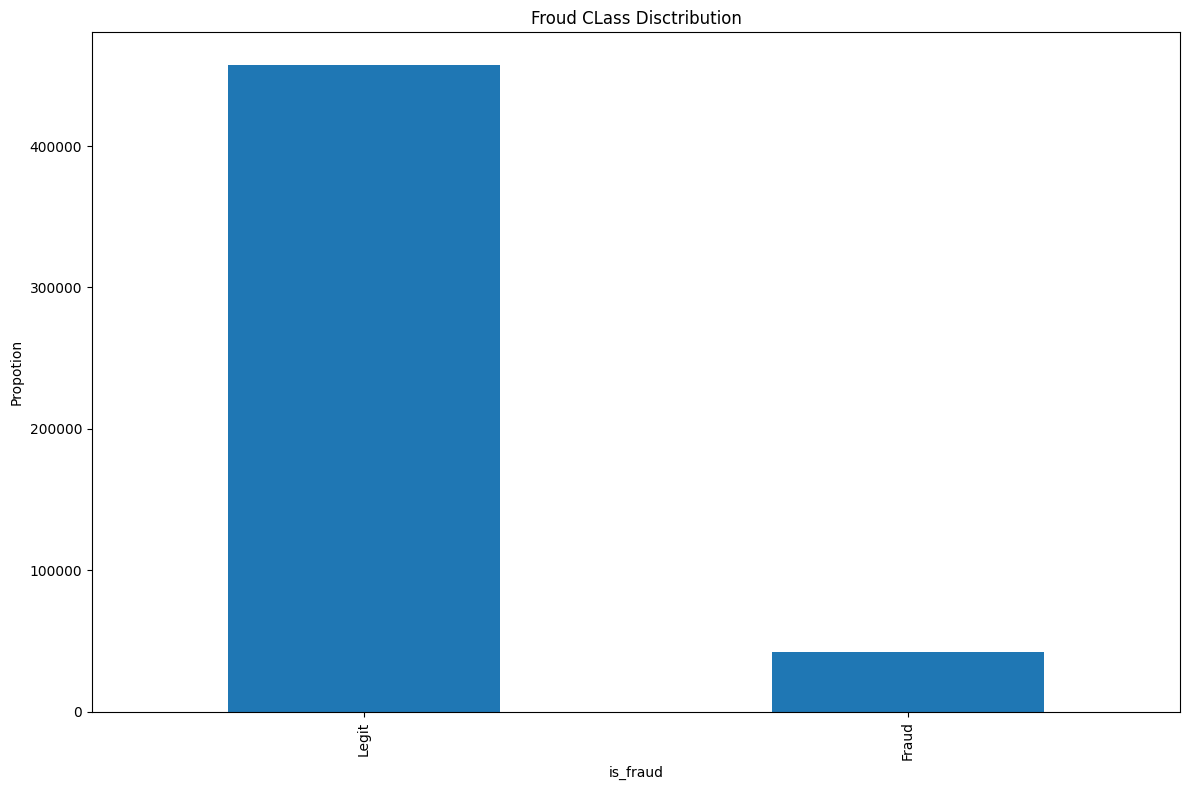

In [35]:
fig, ax = plt.subplots(figsize=(12,8))

fround_counts.plot(kind="bar", ax=ax)
ax.set_title("Froud CLass Disctribution")
ax.set_xticks([0,1])
ax.set_xticklabels(["Legit", "Fraud"])
ax.set_ylabel("Propotion")
plt.tight_layout()
plt.show()

#### Summary: Class distribution is highly imbalanced

- accuracy - will be misleading
- use emetrics like F1-score, Recall, ROC-AUC
- consider resampling (undersampling, oversample)
- use algoritms with built-in support for imbalanced data (e.g. XGBoost)

### Numberical features

<Axes: >

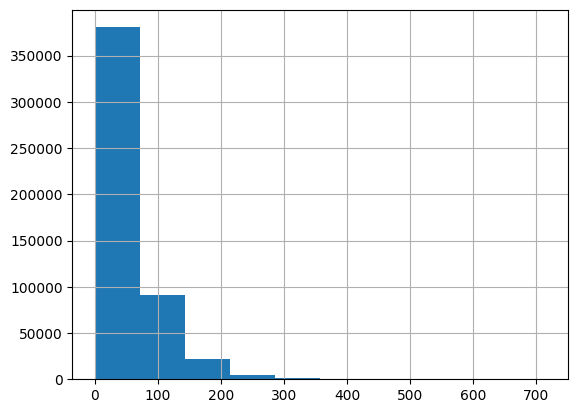

In [37]:
df["amount"].hist()

In [39]:
import numpy as np
def dist_visualisation(
        data: np.ndarray | pd.Series | list,
        title: str = "",
        show: bool = True
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Visualize the distribution of data using boxplot, violinplot, and histogram.

    Args:
        data: Input numerical data to visualize.
        title: Title of the entire figure.
        show: If True, displays the plot. If False, returns the figure and axes.

    Returns:
        Tuple of matplotlib figure and axes dictionary if show=False, otherwise None.
    """
    fig = plt.figure(constrained_layout=True)
    plt.style.use('seaborn-v0_8')

    ax_dict = fig.subplot_mosaic([
        ['boxplot', 'violin'],
        ['histogram', 'violin'],
        ['histogram', 'violin'],
    ])

    mean_props = dict(color="darkorange", linestyle="dashed")

    ax_dict['boxplot'].boxplot(
        data,
        showmeans=True,
        meanline=True,
        meanprops=mean_props,
        vert=False
    )

    violin = ax_dict['violin'].violinplot(
        data,
        showmeans=True,
        showmedians=True
    )
    violin["cbars"].set_linestyle('dotted')

    ax_dict['histogram'].hist(data, bins='sqrt', color='orange')

    ax_dict['violin'].set_xlabel('KDE')
    ax_dict['histogram'].set_ylabel('Count Frequency')

    fig.suptitle(title)

    if not show:
        return fig, ax_dict

    plt.show()
    return None

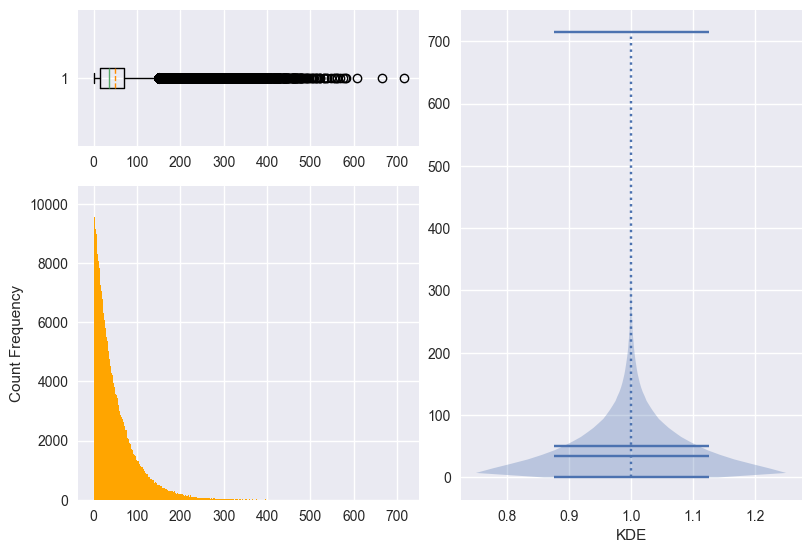

In [41]:
dist_visualisation(df["amount"])

In [44]:
df.loc[df["amount"] <1, "amount"].count()

np.int64(9986)

In [45]:
df["amount"].describe()

count    500000.000000
mean         49.915662
std          49.990657
min           0.000000
25%          14.370000
50%          34.560000
75%          69.172500
max         714.860000
Name: amount, dtype: float64

#### Summary

- amount is strongly right-skewed with a long tail, this suggests the presence of outliners
- recomendation apply log trransformation (e.g. loglp) for algoritms sensitive to discribution shape

In [47]:
df["session_length_seconds"].describe()

count    500000.000000
mean        614.987182
std         338.091496
min          30.000000
25%         323.000000
50%         614.000000
75%         907.000000
max        1200.000000
Name: session_length_seconds, dtype: float64

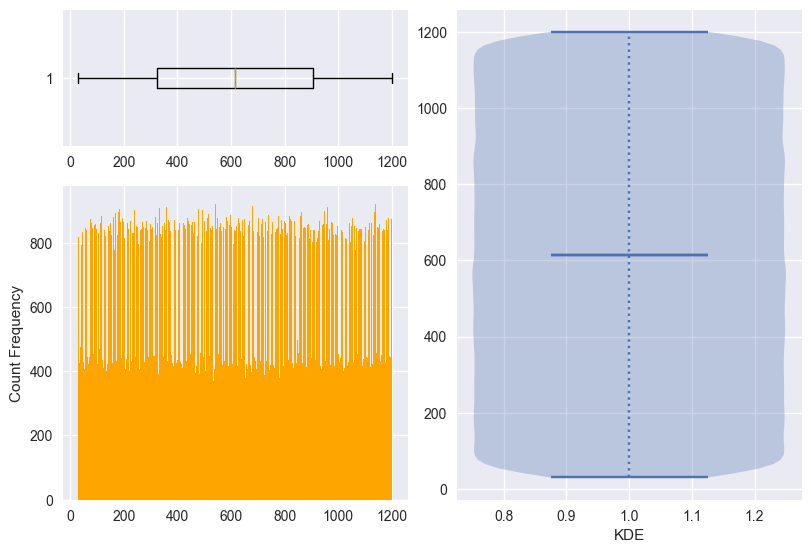

In [48]:
dist_visualisation(df["session_length_seconds"])

Summary
- session_lenght_seconds is uniform distributed, which is unsual in behavioral data
- indicates syntetic generation of flattening
- low predictive power unless frauds are concentrated in specific ranges (to be checked later)

In [50]:
#dist_visualisation(df["timestamp"])
- dane czasowe i lokalizacyjne na potem

# Categorical features

In [52]:
import math

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def dist_categorical_visualisation(
        df: pd.DataFrame,
        categorical_cols: list[str],
        n_cols: int = 2,
        figsize: tuple | None = None,
        title: str | None = "Categorical Feature Distributions",
        save_path: str | None = None
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Plots count distributions for multiple categorical columns using subplots, in a clean and professional style.

    Args:
        df: DataFrame containing the data.
        categorical_cols: List of column names to visualize.
        n_cols: Number of columns in the subplot grid.
        figsize: Size of the entire figure. If None, inferred automatically.
        title: Title of the whole figure.
        save_path: If provided, saves the figure to this path instead of displaying it.
    """

    n = len(categorical_cols)
    n_rows = math.ceil(n / n_cols)
    figsize = figsize or (6 * n_cols, 4.5 * n_rows)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=ax, color="steelblue", edgecolor="black")
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)
        max_val = df[col].value_counts().max()
        ax.set_xlim(0, max_val * 1.1)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    if title:
        fig.suptitle(title, fontsize=16, weight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

    return fig, axes

In [53]:
categorical_cols = ["channel", "currency", "device", "payment_method", "is_international", "is_first_time_merchant"]

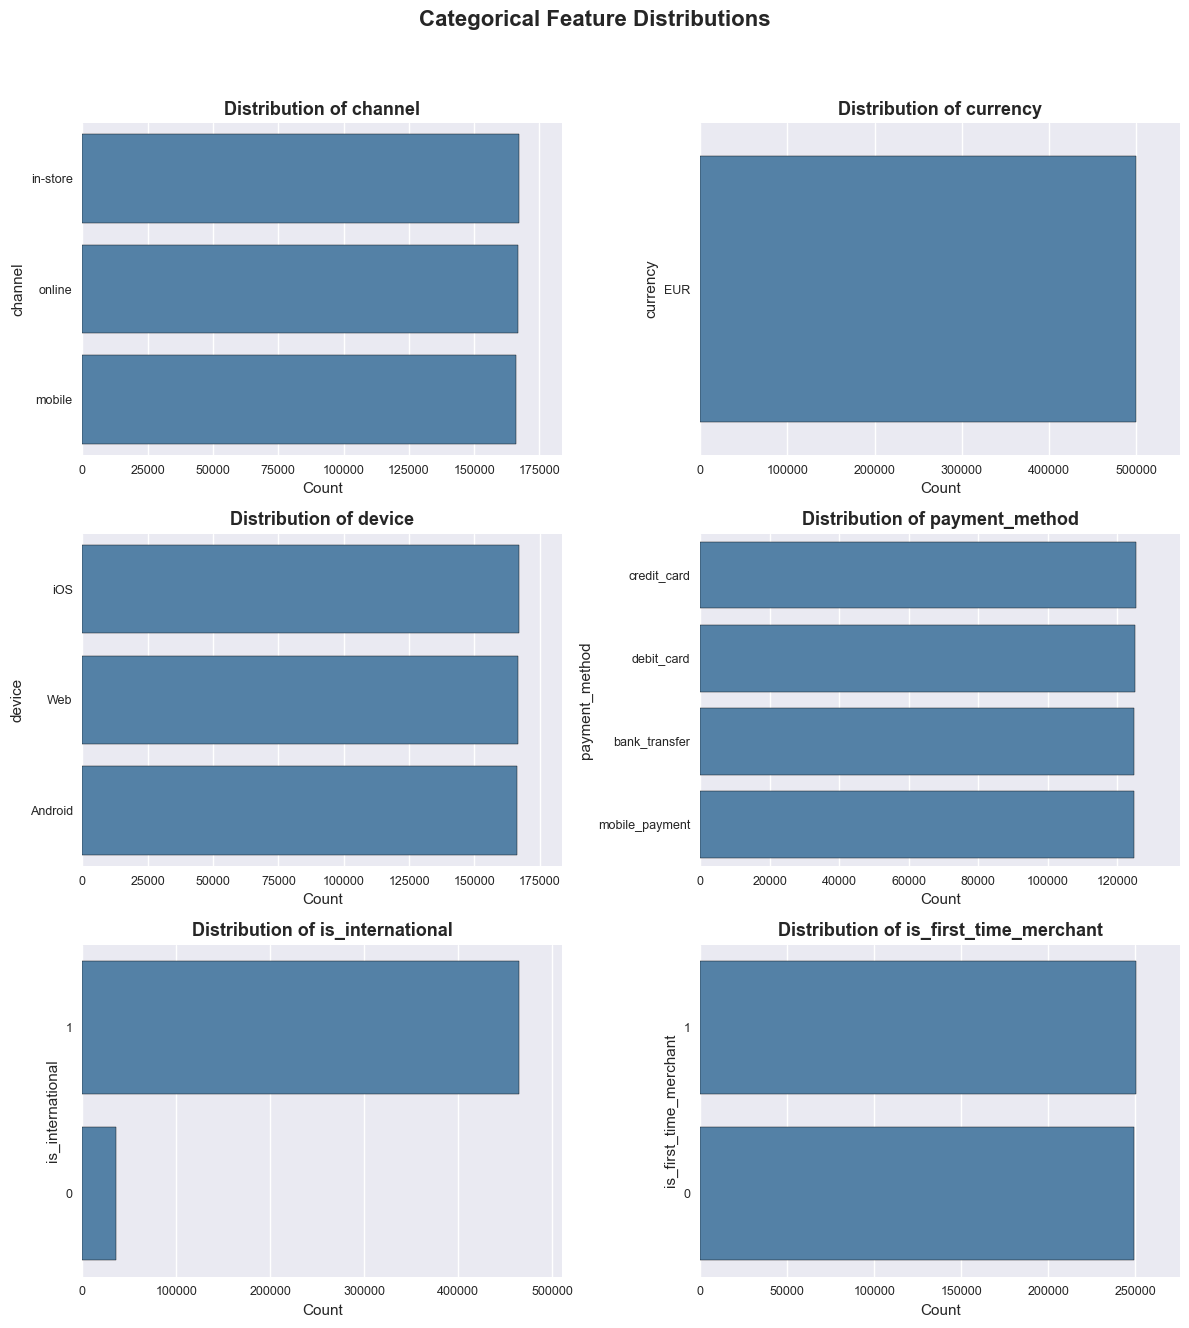

In [54]:
fig, ax = dist_categorical_visualisation(df, categorical_cols)

In [56]:
df["channel"].value_counts()

channel
in-store    167027
online      166847
mobile      166126
Name: count, dtype: int64

#### Summary:
    - channel, device, payment_method show almost perfectly balanced category distribution
    - unusual i real-world and indicates synthetic balancing or controlled generation
    - currency has only one value, making it non-information
    - recommendation: drop this feature
    

## Multivarite analysis



In [60]:
# df.loc[df["is_fraud"] == 1]

#### Amount vs is_fraud

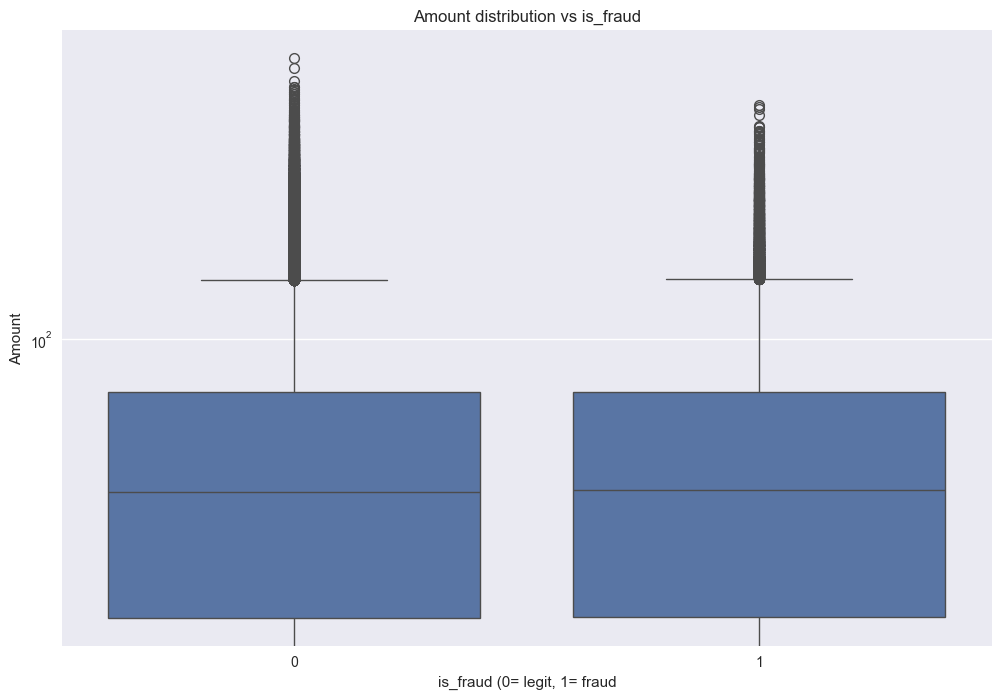

In [64]:
fig, ax = plt.subplots(figsize=(12,8))

sns.boxplot(x="is_fraud", y="amount", data=df, ax=ax)
ax.set_title("Amount distribution vs is_fraud")
ax.set_xlabel("is_fraud (0= legit, 1= fraud")
ax.set_ylabel("Amount")
ax.set_yscale("log") #stosować jak jest dużo outliner

plt.show()

Summary:

- Na podstawie samej wartości transakcji trudno jednoznacznie odróżnić transakcje oszukańcze od legalnych.

- Model detekcji oszustw będzie prawdopodobnie potrzebował dodatkowych cech, ponieważ Amount nie różnicuje wyraźnie klas.

####  session_length_seconds vs is_fraud

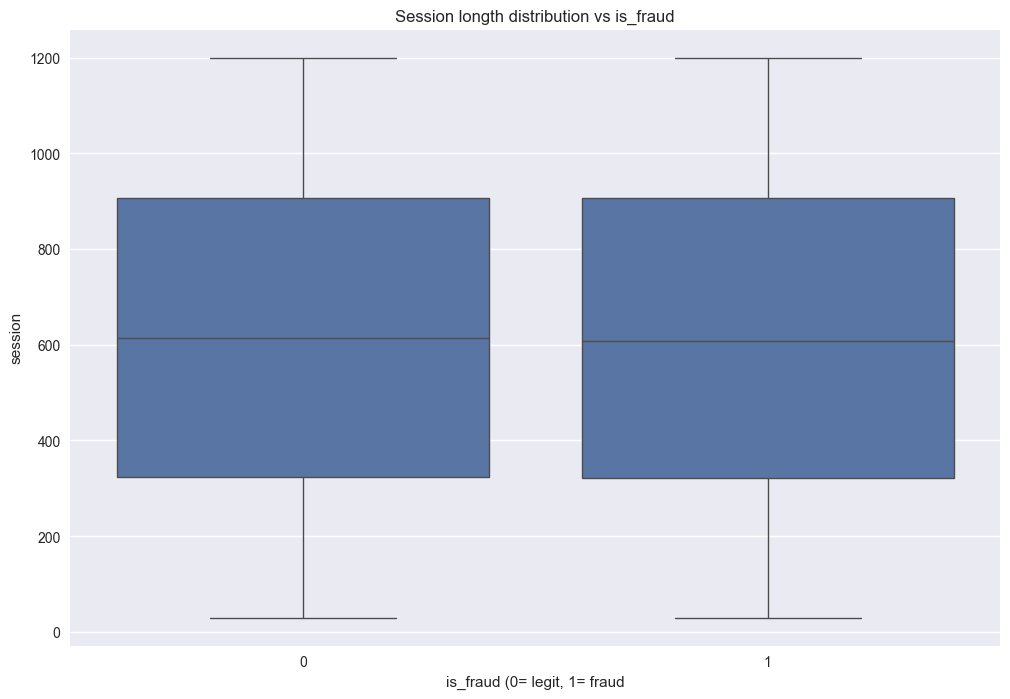

In [68]:
fig, ax = plt.subplots(figsize=(12,8))

sns.boxplot(x="is_fraud", y="session_length_seconds", data=df, ax=ax)
ax.set_title("Session longth distribution vs is_fraud")
ax.set_xlabel("is_fraud (0= legit, 1= fraud")
ax.set_ylabel("session")


plt.show()

### Time-base analysis

In [13]:
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek

In [14]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud,hour,dayofweek
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0,23,4
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0,15,1
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0,21,4
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0,6,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0,8,3


In [17]:
df_ts = df.set_index("timestamp").sort_index()

In [19]:
fraud_counts= df_ts.resample("W")["is_fraud"].sum()
total_counts= df_ts.resample("W")["is_fraud"].count()
fraud_rate = (fraud_counts / total_counts).fillna(0)

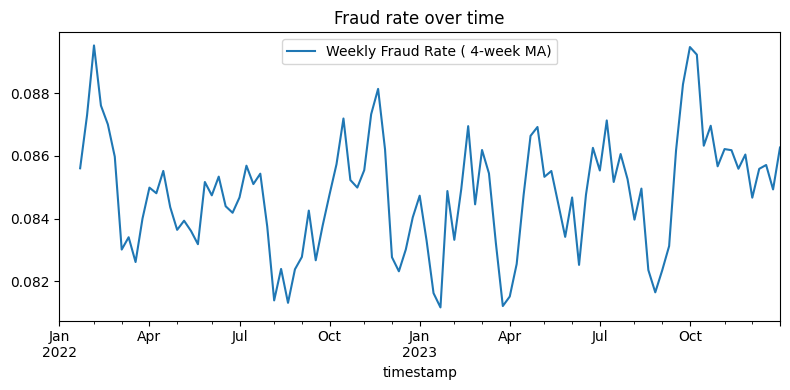

In [24]:
fig, ax = plt.subplots(figsize=(8,4))

fraud_rate.rolling(4).mean().plot(ax=ax, label="Weekly Fraud Rate ( 4-week MA)")

ax.set_label("Fraud rate")
ax.set_title("Fraud rate over time")
# ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()
plt.show()

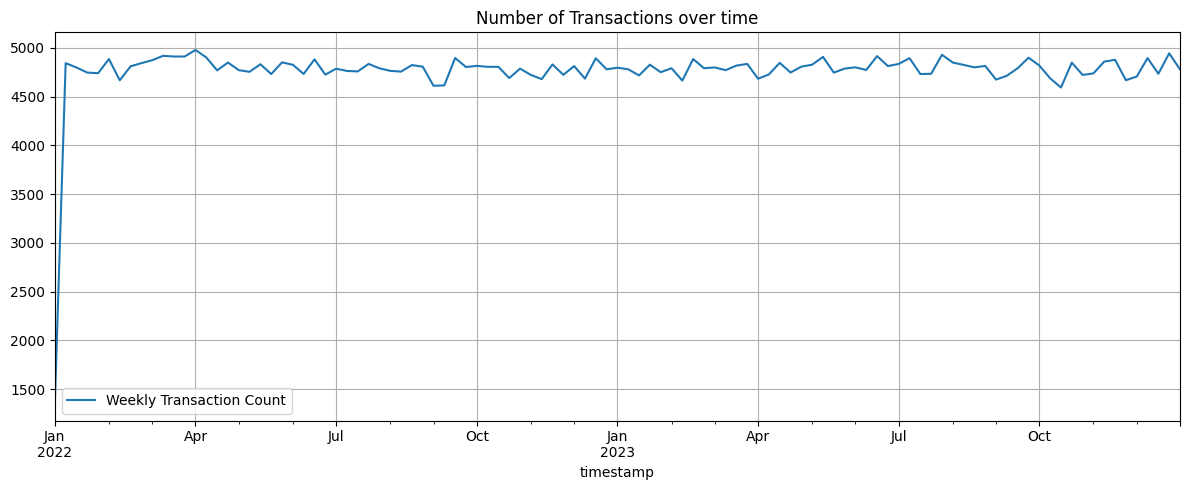

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

total_counts.plot(ax=ax, label="Weekly Transaction Count")

ax.set_label("Transaction Count")
ax.set_title("Number of Transactions over time")

ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

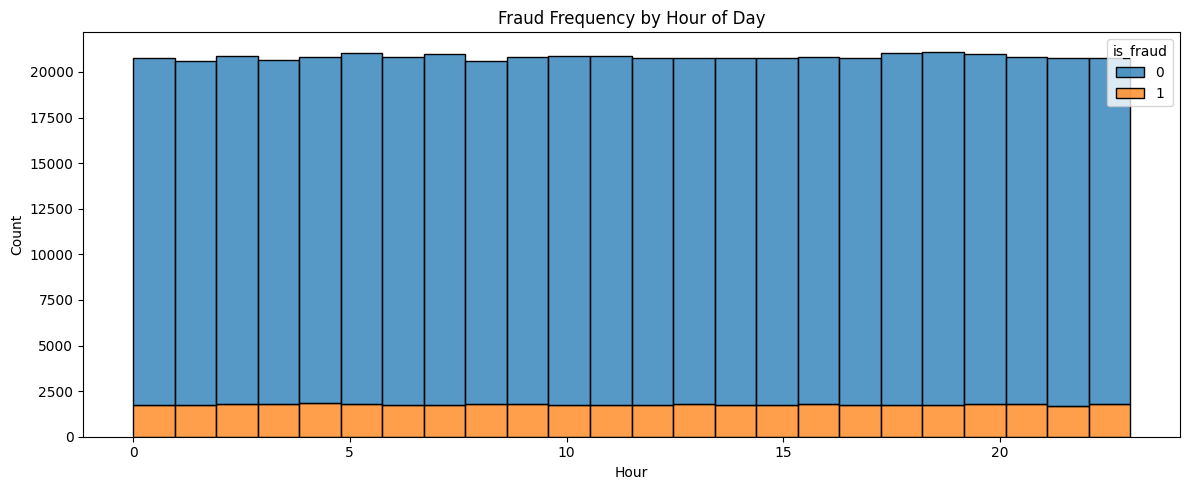

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df_ts, x="hour", hue="is_fraud", bins=24, ax=ax, multiple="stack")

ax.set_xlabel("Hour")
ax.set_ylabel("Count")
ax.set_title("Fraud Frequency by Hour of Day")


fig.tight_layout()
plt.show()

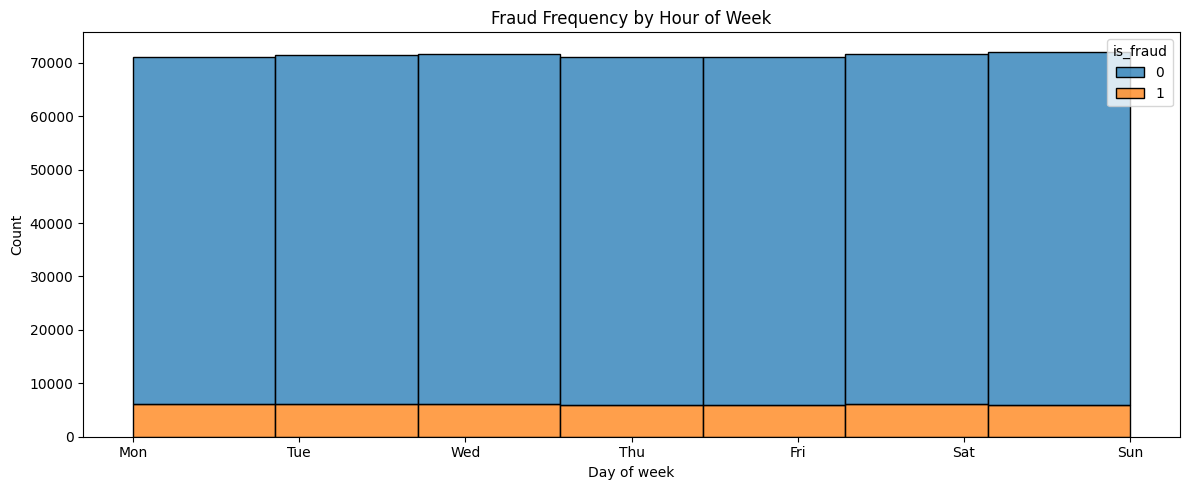

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df_ts, x="dayofweek", hue="is_fraud", bins=7, ax=ax, multiple="stack")

ax.set_xlabel("Day of week")
ax.set_xticks(range(7))
ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])


ax.set_ylabel("Count")
ax.set_title("Fraud Frequency by Hour of Week")


fig.tight_layout()
plt.show()

#### 1. Fraud Rate Over Time (weekly trend)
- The fraud rate fluctuates mildly between ~8.1% and 8.9% over the two-year span.
- No clear upward or downward trend, but some short-term volatility is present.
- Suggests that fraud behavior is stationary over time (non-seasonal).

#### 2. Fraud Frequency by Hour of Day
- Fraud and legit transactions are evenly distributed across all hours.
- No visible peak during night or business hours.
- Indicates time of day likely has no predictive signal.

#### 3. Average Fraud Rate by Day of Week
- All days show nearly equal fraud rates (~8.5%).
- No significant weekday vs. weekend pattern.

### Summary
- Time-based features appear non-informative in isolation.
- Their value may emerge only through interactions or in tree-based models.
- Results align with the synthetic structure of the dataset.

### Korelacja matrix


In [36]:
features = ["amount","session_length_seconds","is_fraud"]
corr = df_ts[features].corr()
corr

,amount,session_length_seconds,is_fraud
amount,1.000000,0.000056,0.002197
session_length_seconds,0.000056,1.000000,-0.001980
is_fraud,0.002197,-0.001980,1.000000


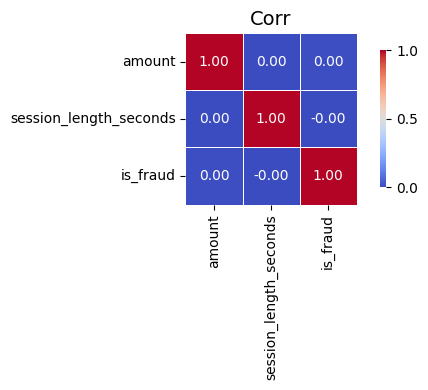

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,           # poprawka: powinno być 'annot' zamiast 'annotation'
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("Correlation Heatmap", fontsize=14)
plt.tight_layout()       # poprawka: tight_layout, nie tight_lauout
plt.show()

#### Implication
- decision tree, boosting, neural nets - któryś z tym modeli może być bo nie ma tutaj zapleżności liniowych